In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots

/home/nlonyuk/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv('../../cp/results_base1_tfd.csv')
df = df.drop_duplicates(subset=['config','num_trains'])
df

,Unnamed: 0.6,config,num_trains,num_expansions,makespan,makespan_pp,search_time,Unnamed: 0.5,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0
0,0,19.0,3.0,6211.0,135.0,90.0,270.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,19.0,4.0,3983.0,186.0,136.0,260.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,19.0,5.0,1727.0,286.0,147.0,240.0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,19.0,6.0,1144.0,331.0,201.0,210.0,NaN,NaN,NaN,NaN,NaN,NaN
4,4,17.0,3.0,199571.0,108.0,116.0,290.0,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,99,9.0,7.0,4389.0,377.0,239.0,21.0,95.0,84.0,41.0,29.0,NaN,NaN
100,100,9.0,8.0,1051.0,536.0,379.0,10.0,96.0,85.0,42.0,30.0,NaN,NaN
101,101,9.0,9.0,6839.0,563.0,427.0,110.0,97.0,86.0,43.0,31.0,NaN,NaN
102,102,9.0,10.0,4719.0,624.0,462.0,90.0,98.0,87.0,44.0,32.0,NaN,NaN


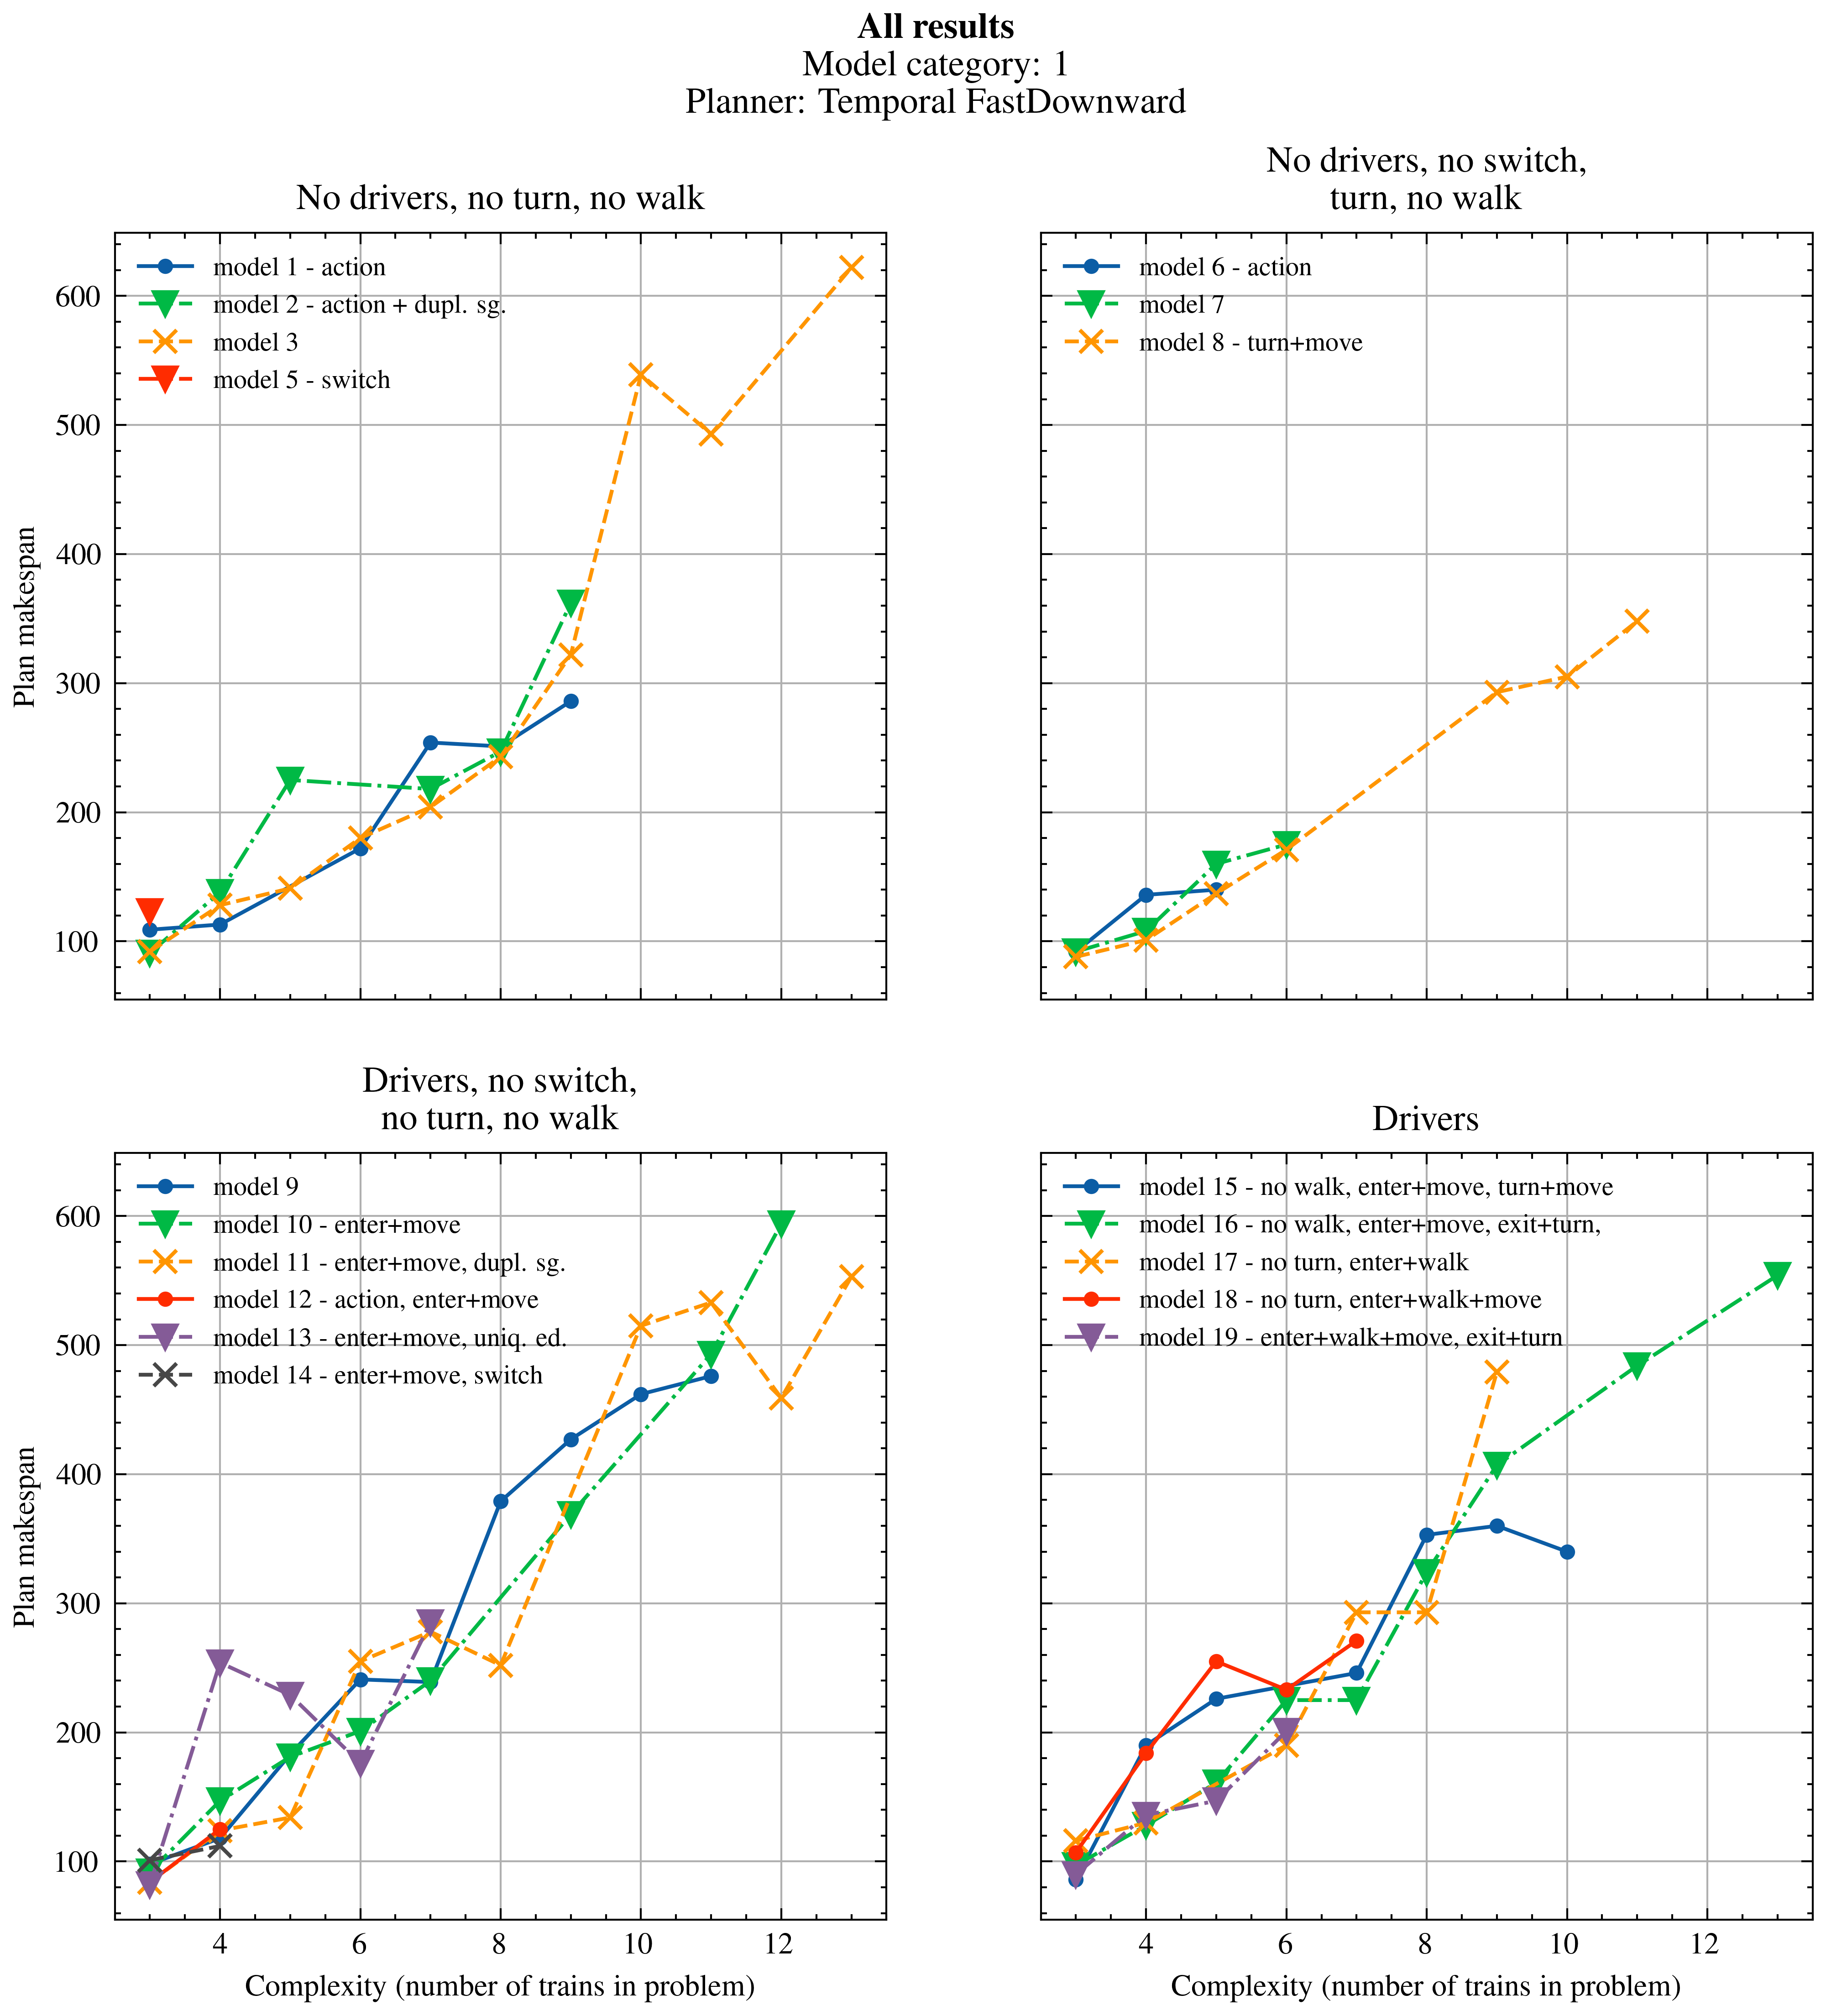

In [3]:
plt.style.use(['ieee', 'science'])

groups = [[1,2,3,4,5],[6,7,8],[9,10,11,12,13,14],[15,16,17,18,19]]
labels = [['- action','- action + dupl. sg.','','- uniq. ed.','- switch'],
          ['- action', '', '- turn+move'],
          ['', '- enter+move','- enter+move, dupl. sg.','- action, enter+move','- enter+move, uniq. ed.', '- enter+move, switch'],
          ['- no walk, enter+move, turn+move', '- no walk, enter+move, exit+turn,', '- no turn, enter+walk', '- no turn, enter+walk+move', '- enter+walk+move, exit+turn'],
          ]
group_x, group_y = [], []
for group in groups:
    x, y = [], []
    for cfg in group:
        df_filt = df.query(f"config=={cfg}")
        # df_filt = df_filt[df_filt['makespan'] > 0]
        x.append(list(df_filt['num_trains']))
        y.append(list(df_filt['makespan_pp']))
    group_x.append(x)
    group_y.append(y)

fig, ax = plt.subplots(2,2, figsize=(8,8), sharey=True, sharex=True)
ax = ax.flatten()
fig.suptitle(r"""\textbf{All results}
             Model category: 1
             Planner: Temporal FastDownward""")

for i in range(len(groups)):
    for j in range(len(group_x[i])):
        if len(group_x[i][j]) <= 0 or len(group_y[i][j]) <= 0:
            continue
        if j % 3 == 0:
            dots = '.-'
        elif j % 3 == 1:
            dots = 'v-.'
        else:
            dots = 'x--'
        ax[i].plot(group_x[i][j], group_y[i][j], dots, label=f'model {groups[i][j]} {labels[i][j]}', linewidth=1)
        ax[i].legend(loc='upper left', fontsize=7)
        ax[i].grid(True)
        # # ax[i].set_xlabel('Number of trains in problem')
        ax[i].xaxis.set_major_locator(MaxNLocator(integer=True))

ax[0].set_ylabel('Plan makespan')
ax[2].set_ylabel('Plan makespan')
ax[2].set_xlabel('Complexity (number of trains in problem)')
ax[3].set_xlabel('Complexity (number of trains in problem)')

ax[0].set_title('No drivers, no turn, no walk')
ax[1].set_title('No drivers, no switch,\n turn, no walk')
ax[2].set_title('Drivers, no switch,\n no turn, no walk')
ax[3].set_title('Drivers')

# fig.tight_layout()
fig.savefig('tfd_base1_makespans.png')


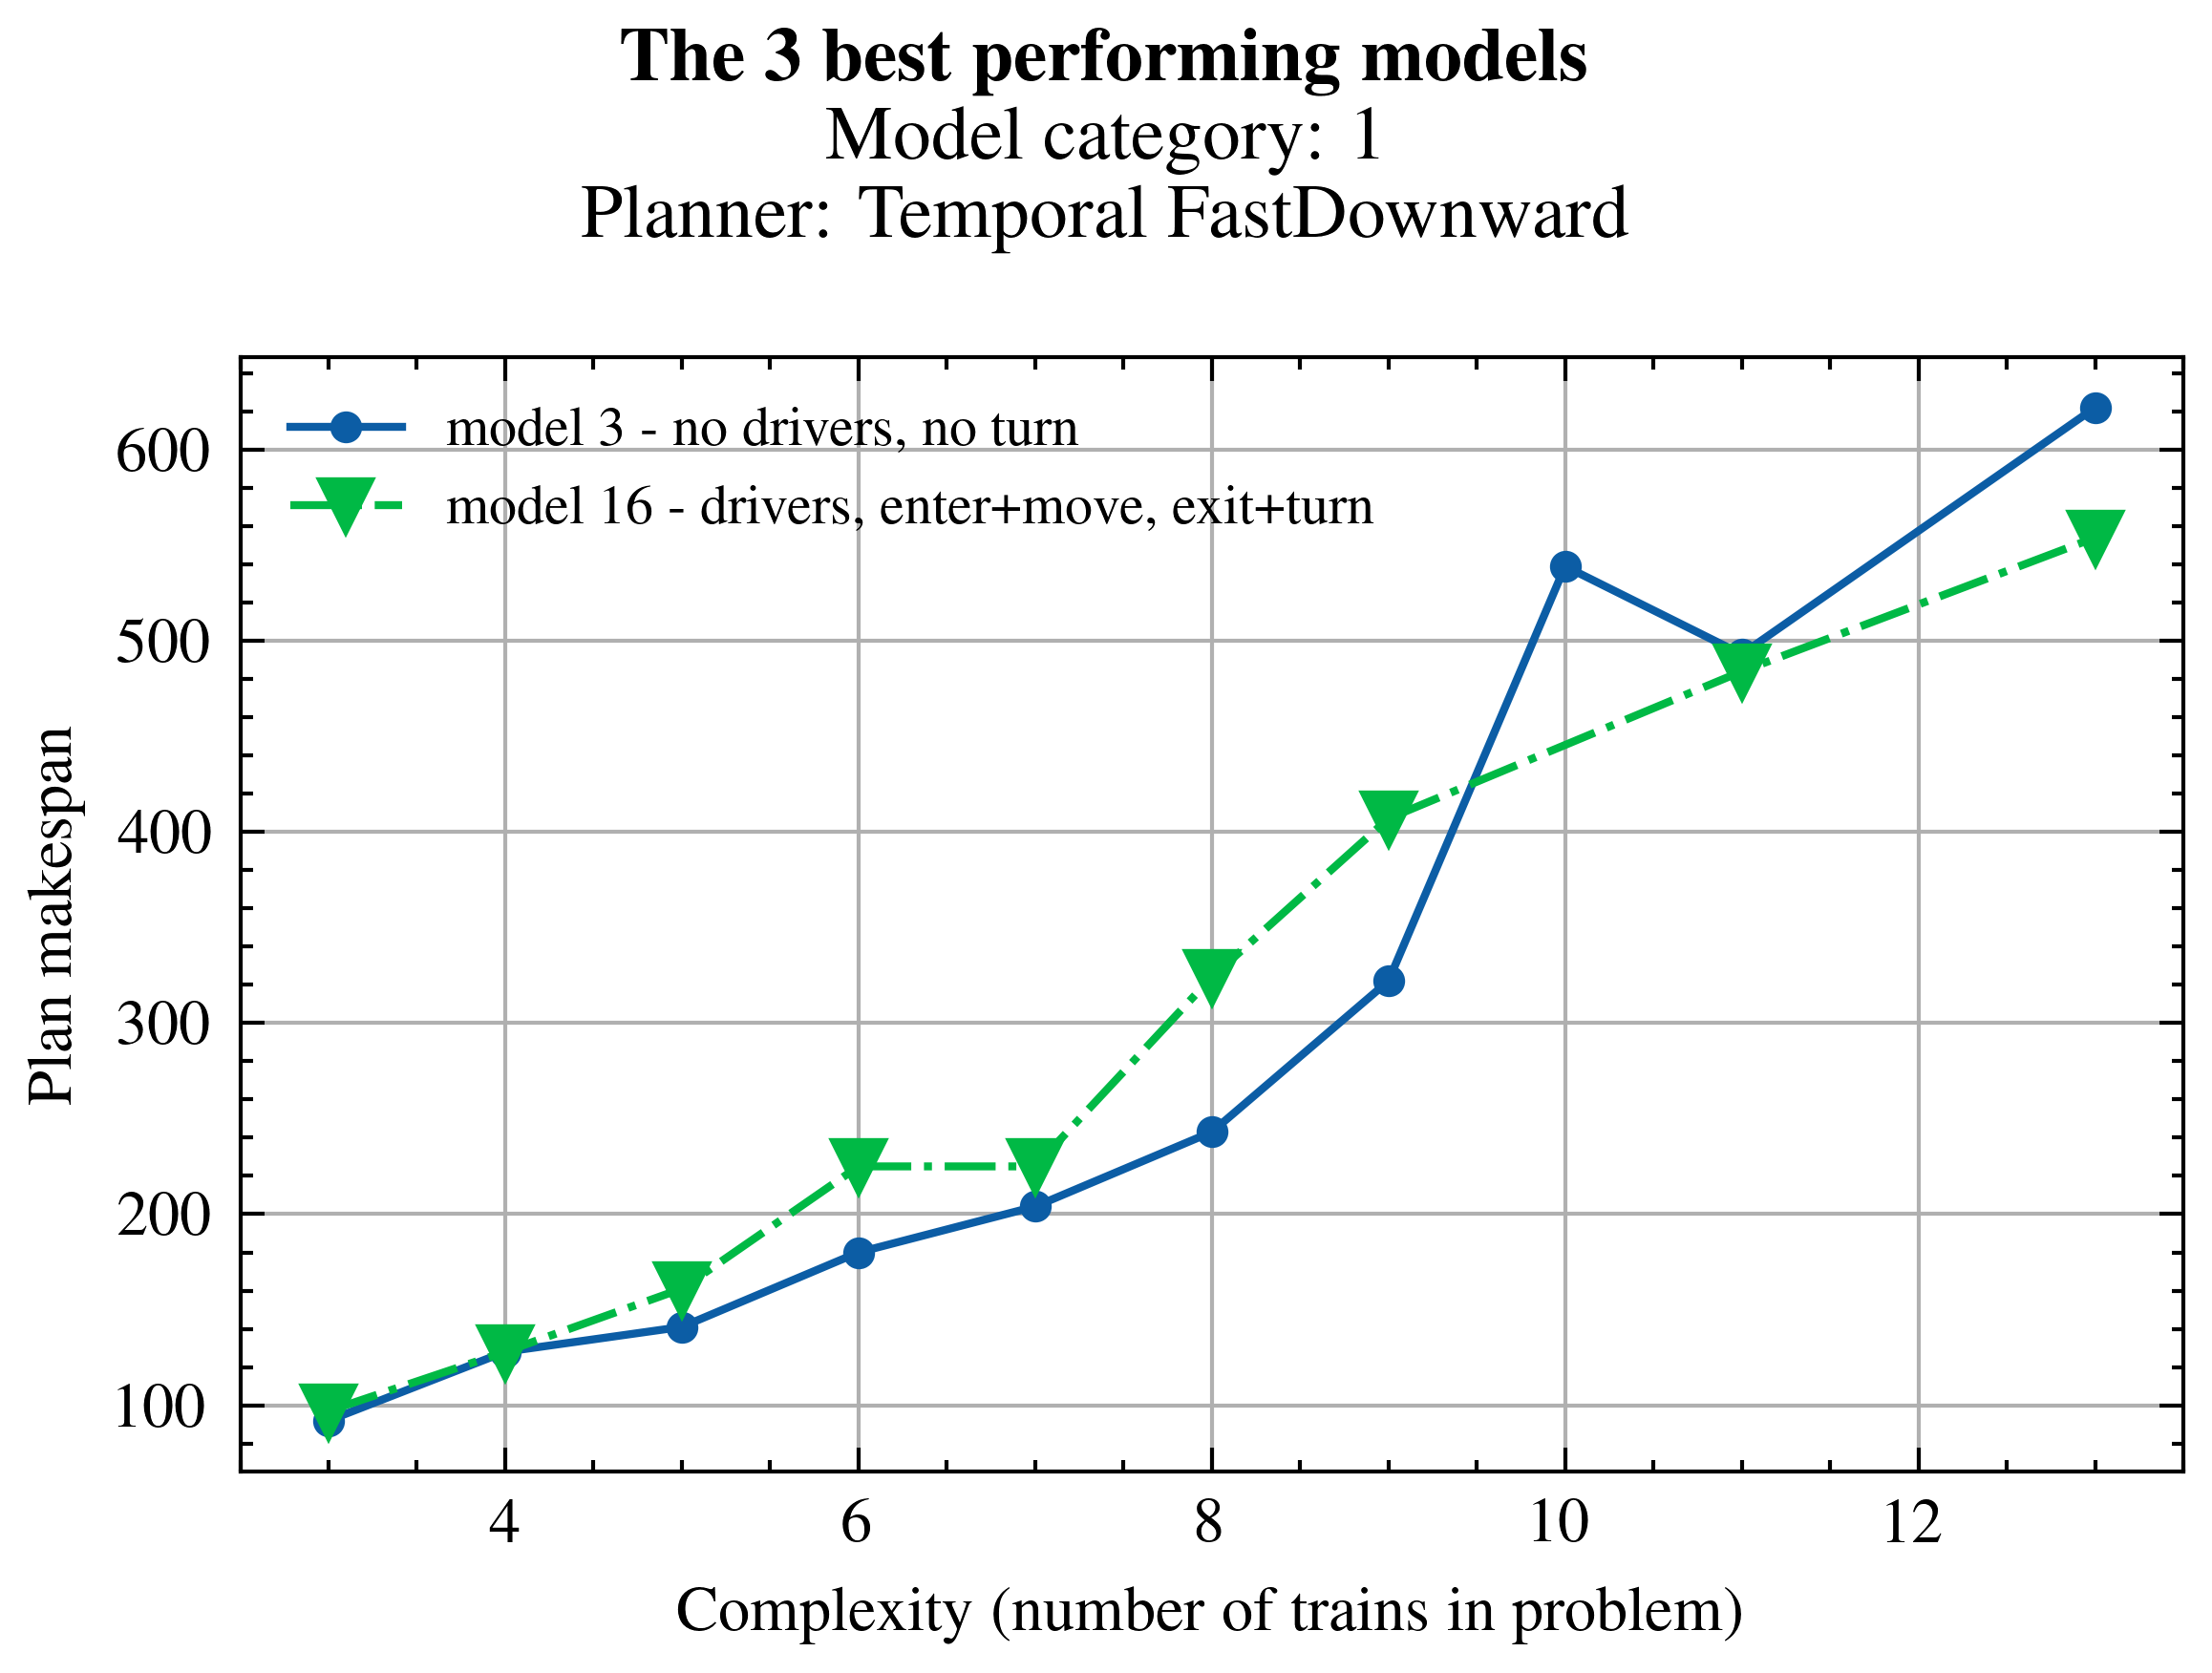

In [4]:
plt.style.use(['ieee', 'science'])

groups = [[3,16]]
labels = [
    ['- no drivers, no turn','- drivers, enter+move, exit+turn']
]

group_x, group_y = [], []
for group in groups:
    x, y = [], []
    for cfg in group:
        df_filt = df.query(f"config=={cfg}")
        # df_filt = df_filt[df_filt['makespan'] > 0]
        x.append(list(df_filt['num_trains']))
        y.append(list(df_filt['makespan_pp']))
    group_x.append(x)
    group_y.append(y)

fig, ax = plt.subplots(1,1, figsize=(4,3), sharey=True, sharex=True)
# ax = ax.flatten()
fig.suptitle(r"""\textbf{The 3 best performing models}
             Model category: 1
             Planner: Temporal FastDownward""")
configs = ['.-',  'v-.']

for i in range(len(groups)):
    for j in range(len(group_x[i])):
        ax.plot(group_x[i][j], group_y[i][j], configs[j], label=f'model {groups[i][j]} {labels[i][j]}', linewidth=1)
        ax.legend(loc='upper left', fontsize=7)
        ax.grid(True)
        # ax[i].set_xlabel('Number of trains in problem')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylabel('Plan makespan')
ax.set_xlabel('Complexity (number of trains in problem)')

fig.tight_layout()
fig.savefig('tfd_base1_makespans_pp.png')
